In [ ]:
#%pip install -r ../requirements.txt -q


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub
import os
import shutil

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Create the data/raw directory if it doesn't exist
os.makedirs("../data/raw", exist_ok=True)

path = kagglehub.dataset_download("sriharshaeedala/financial-fraud-detection-dataset")
print("Dataset downloaded to:", path)

target_dir = "../data/raw/financial-fraud-detection-dataset"
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)
shutil.copytree(path, target_dir)
print(f"Dataset copied to: {target_dir}")

path = target_dir

100%|██████████| 178M/178M [00:32<00:00, 5.71MB/s] 

Extracting files...


Dataset downloaded to: /Users/kayi/.cache/kagglehub/datasets/sriharshaeedala/financial-fraud-detection-dataset/versions/1
Dataset copied to: ../data/raw/financial-fraud-detection-dataset


In [5]:
csv_file = os.path.join(path, "Synthetic_Financial_datasets_log.csv")
print(f"Looking for file at: {csv_file}")


df = pd.read_csv(csv_file)
df.head()

Looking for file at: ../data/raw/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
# class distribution
label_col = "isFraud"

counts = df[label_col].value_counts(dropna=False).sort_index()
pct = df[label_col].value_counts(normalize=True, dropna=False).sort_index() * 100

print("\n=== Class distribution (isFraud) ===")
for k in counts.index:
    print(f"{k}: {counts[k]:,}  ({pct[k]:.4f}%)")
imbalance_ratio = (counts.get(0, 0) / max(counts.get(1, 1), 1)) if 1 in counts else np.inf
print(f"Imbalance ratio (Non-fraud : Fraud) ≈ {imbalance_ratio:.1f}:1")


=== Class distribution (isFraud) ===
0: 6,354,407  (99.8709%)
1: 8,213  (0.1291%)
Imbalance ratio (Non-fraud : Fraud) ≈ 773.7:1


# Data Preprocessing
- drop useless columns
- convert isFraud to boolean
- onehotencode "type"
- train-test split (stratified)
- smote

In [9]:
# remove unuse columns
df.drop(['step', 'nameOrig', 'nameDest'], axis=1, inplace=True)

# covert data type of some columns
df['isFraud'] = df['isFraud'].astype(bool)
df['isFlaggedFraud'] = df['isFlaggedFraud'].astype(bool)

# encodeing categorical vaiables
encoder = OneHotEncoder(sparse_output=False)
type_col = df['type'].values.reshape(-1, 1)
encoded_cols = encoder.fit_transform(type_col)
df = df.reset_index(drop=True)
df_encoded = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(['type']))
encoded_data = df.drop(columns=['type'])
encoded_data = pd.concat([encoded_data, df_encoded], axis=1)
encoded_data.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9839.64,170136.0,160296.36,0.0,0.0,False,False,0.0,0.0,0.0,1.0,0.0
1,1864.28,21249.0,19384.72,0.0,0.0,False,False,0.0,0.0,0.0,1.0,0.0
2,181.00,181.0,0.00,0.0,0.0,True,False,0.0,0.0,0.0,0.0,1.0
3,181.00,181.0,0.00,21182.0,0.0,True,False,0.0,1.0,0.0,0.0,0.0
4,11668.14,41554.0,29885.86,0.0,0.0,False,False,0.0,0.0,0.0,1.0,0.0


### Train-Test Split

In [ ]:
# split data into features and target
X = encoded_data.drop(columns=['isFraud'])
y = encoded_data['isFraud']

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Applying SMOTE

In [11]:
# apply SMOTE to the training data only
smote = SMOTE(random_state=42)
X_train_smoted, y_train_smoted = smote.fit_resample(X_train, y_train)

smote_df = pd.concat([X_train_smoted, y_train_smoted], axis=1).reset_index(drop=True)

# class distribution after smote
counts = smote_df[label_col].value_counts(dropna=False).sort_index()
pct = smote_df[label_col].value_counts(normalize=True, dropna=False).sort_index() * 100

print("\n=== Class distribution (isFraud) ===")
for k in counts.index:
    print(f"{k}: {counts[k]:,}  ({pct[k]:.4f}%)")
imbalance_ratio = (counts.get(0, 0) / max(counts.get(1, 1), 1)) if 1 in counts else np.inf
print(f"Imbalance ratio (Non-fraud : Fraud) ≈ {imbalance_ratio:.1f}:1")



=== Class distribution (isFraud) ===
False: 5,083,526  (50.0000%)
True: 5,083,526  (50.0000%)
Imbalance ratio (Non-fraud : Fraud) ≈ inf:1


/var/folders/hz/w33z2_s56bv9417650gj0c5h0000gn/T/ipykernel_79118/2771627071.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/kayi/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


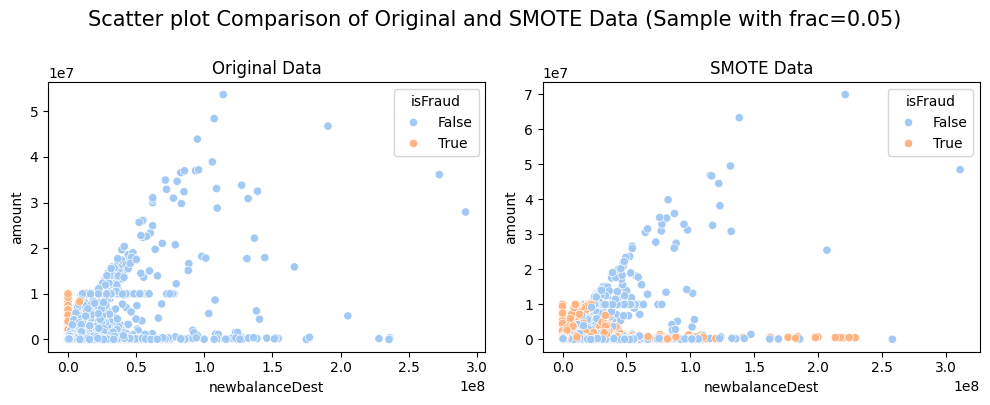

In [13]:
# plots that show smote creates new fraudulent transactions similar but not identical to original ones
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
frac = 0.05

# First subplot
sns.scatterplot(x="newbalanceDest", y="amount", hue="isFraud", data=df.sample(frac=frac, random_state=42), palette="pastel", ax=axes[0])
axes[0].set_title("Original Data")

# Second subplot
sns.scatterplot(x="newbalanceDest", y="amount", hue="isFraud", data=smote_df.sample(frac=frac, random_state=42), palette="pastel", ax=axes[1])
axes[1].set_title("SMOTE Data")

fig.suptitle('Scatter plot Comparison of Original and SMOTE Data (Sample with frac=0.05)', fontsize=15, y=1)
plt.tight_layout()
plt.show()

### Save as CSV

In [ ]:
# train_df = pd.concat([X_train_smoted, y_train_smoted], axis=1).reset_index(drop=True)
# train_df.to_csv('financial_fraud_train_smoted.csv', index=False)
# print("SMOTEd training dataset saved as financial_fraud_train_smoted.csv")

# test_df = pd.concat([X_test, y_test], axis=1).reset_index(drop=True)
# test_df.to_csv('financial_fraud_test_set.csv', index=False)
# print("Test dataset saved as financial_fraud_test_set.csv")


In [ ]:
# import pandas as pd

# test_df = pd.read_csv('financial_fraud_test_set.csv')
# train_df = pd.read_csv('financial_fraud_train_smoted.csv')

# X_test = test_df.drop(columns=['isFraud'])
# y_test = test_df['isFraud']

# X_train = train_df.drop(columns=['isFraud'])
# y_train = train_df['isFraud']

